In [21]:
import numpy as np
import pandas as pd
import geocat.comp as gcat

import matplotlib.pyplot as mp
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
#from mpl_toolkits.basemap import Basemap as bmap
#import shapely.geometry as sgeom
import cftime
#from datetime import timedelta

import xarray as xr
#import datetime as dt
#import cartopy.crs as ccrs
#import cartopy.feature as cfeature

from scipy import signal
from scipy.stats import gaussian_kde

from metpy.calc import mean_pressure_weighted
from metpy.units import units

from distributed import Client
from ncar_jobqueue import NCARCluster

In [22]:
cluster = NCARCluster()
cluster.scale(jobs=18)

client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/dask_jobqueue/core.py:274: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWa

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.148.0.6:37633,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [23]:


date_range = ["0001-01-01","0002-01-01"]
vars_p = ['T']


#run_names = ['f.e20.FHIST.f09_f09.cesm2_1.001','f.e20.FHIST.f09_f09.cesm2_1_cam5.001','f.e20.FHIST.f09_f09.cesm2_1_cam5_zmconv.001','f.e20.FHIST.f09_f09.cesm2_1_mg1.002','f.e20.FHIST.f09_f09.cesm2_1_revert125.001',
#                'f.e20.FHIST.f09_f09.cesm2_1_revertcam5param.001','f.e20.FHIST.f09_f09.cesm2_1_L30.001','f.e20.FHIST.f09_f09.cesm2_1_sb.001']
#case_names = ['CAM6','CAM5','zmconv','mg1','125','cam5-params','L30','sb1']
#run_names = ['f.e20.FHIST.f09_f09.cesm2_1.001','obs','obs']
#case_names = ['CAM6','TRMM','ERA5']

run_name = 'f.e20.FHIST.f09_f09.cesm2_1.001'
case = 'CAM6'







lrm_mean = True



#run_names = ['f.e20.FHIST.f09_f09.cesm2_1.001']
#case_names = np.array(['CAM6'])

#run_names = ['f.e20.FHIST.f09_f09_cesm2_1_cam5.001']
#case_names = np.array(['CAM5'])









#var_name = 'ZMDQ' ; vscale = 86400*1000. ; vunits = 'g/kg/day' ; long_name = 'Humidity Tendency due to Deep Convection'
#var_name = 'ZMDT' ; vscale = 86400. ; vunits = 'g/kg/day' ; long_name = 'Temperature Tendency due to Deep Convection'
#var_name = 'Q' ; vscale = 1000. ; vunits = 'g/kg' ; long_name = 'Specific Humidity'
#var_name = 'OMEGA' ; vscale = 0.01*3600. ; vunits = 'mb/day' ; long_name = 'Vertical Velocity'
#var_name = 'RVMTEND_CLUBB' ; vscale = 86400*1000. ; vunits = 'g/kg/day' ; long_name = 'Humidity Tendency due to CLUBB'
#var_name = 'CMFDQ' ; vscale = 86400*1000. ; vunits = 'g/kg/day' ; long_name = 'Humidity Tendency due to UW Shallow Convection'



In [24]:
## Plots ##
pdir = '/glade/u/home/rneale/python/python-figs/vert_proc/transition_pod/'


## Derived ##

#case_names = np.array(case_names)
#vars_p = np.array(vars_p)

#ncases = case_names.size
#nvars = vars_p.size
# Region


### Variables 


vars_1d = ['TS','PRECT','LHFLX','OMEGA500','PREH2O']

variables = {}
variables['TS'] = ['Sea Surface Temperature','K',1.,301,303,2]  
variables['PRECT'] = ['Precipitation','mm/day',86400.*1000.,0,20,2] 
variables['LHFLX'] = ['Surface Latent Heat Flux','W/m^2',1.,80,250,2] 

variables['T'] = ['Temperature','K',1.,-2,2,0.2]  
variables['DIV'] = ['Divergence','/s',1.,-2e-5,2e-5,0.2e-5]  
variables['Q'] = ['Specific Humidity','g/kg',1000.,-2,2,0.2]  
variables['ZMDT'] = ['Temperature Tendency due to Deep Convetion','K/day',86400,-5,5,1]  
variables['ZMDQ'] = ['Humidity Tendency due to Deep Convection','g/kg',86400.*1000.,-2,2,0.2] 
variables['OMEGA'] = ['Vertical Velocity','pa/s',1.,-0.05,0.05,0.005] 
variables['RVMTEND_CLUBB'] = ['Humidity Tendency due to Moist Turbulence','g/kg/day',86400*1000,-1,1,0.1] 
variables['DQDT'] = ['Resolved Humidity Tendency','g/kg/day',86400*1000,-1,1,0.1]

vars_df = pd.DataFrame.from_dict(variables, orient='index',columns=['long_name','vunits','vscale','cmin','cmax','dcont'])













/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/xarray/coding/times.py:716: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/xarray/core/indexing.py:529: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

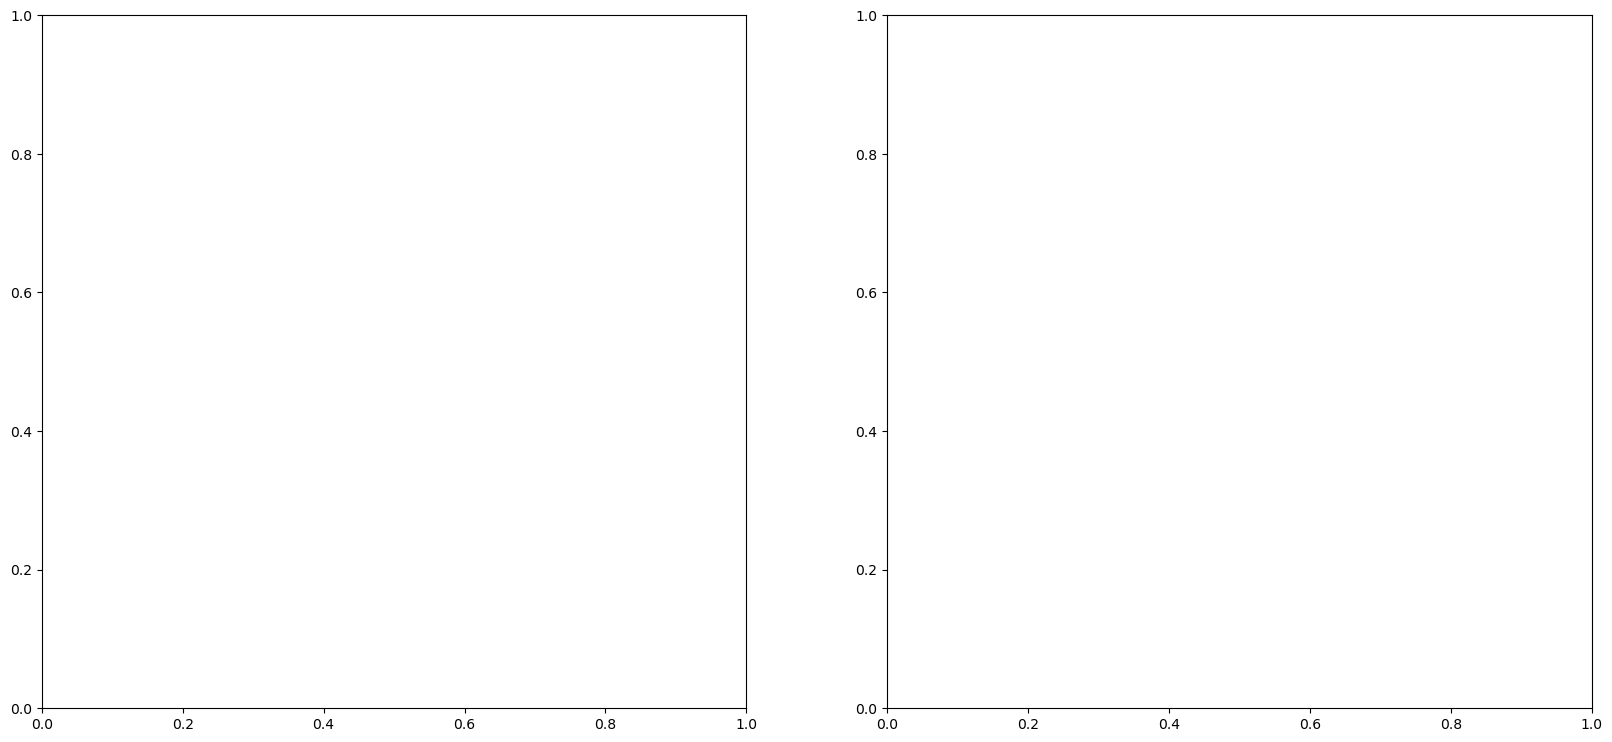

In [25]:

fig, axs = mp.subplots(1,2,figsize=[20,9])

# Read in variables

var1_name = 'PRECT' ; long_name1 = 'Total Precipitation (mm/day)' ; cvscale1 = 86400.*1000. ; ovscale1 = 24.*1000.  ; yrange = [0,20]
#var2_name = 'LHFLX' ; long_name2 = 'Latent Heat Flux (W/m^2)'     ; cvscale2 = 1.           ; ovscale2 = -1./3600.  ; xrange =  [80,180] 
#var2_name = 'PREH2O' ; var2_3d = 'Q' ;  long_name2 = 'Precipitable Water (mm)'     ; cvscale2 = 1.       ; ovscale2 = 1.  ; xrange =  [25,60] 
var2_name = 'Q850' ; var2_3d = 'Q' ;  long_name2 = '850-mb Specific Humidity (mm)'  ; plev = 850. ;  cvscale2 = 10000.      ; ovscale2 = 1000.  ; xrange =  [0,20] 

#var2_name = 'Q' ; vscale2 = 1000. ; long_name2 = 'Specific Humidity (g/kg)'
#var2_name = 'ZMDQ' ; vscale2 = 1000.*86400. ; long_name2 = 'Deep Convective Moistening (g/kg/day)'
#var2_name = 'RVMTEND_CLUBB' ; vscale2 = 1000. ; long_name2 = 'CLUBB Moistening (g/kg/day)'

#reg_a = [7.,12.,140.,160.]     ; reg_name = 'West Pacific'   # Central Pacific
#reg_a = [-5.,5.,160.,200.]     ; reg_name = 'Central Pacific'      # East Pacific
#reg_a = [7.5,12,220.,240]  ; reg_name = 'East Pacific'      # West Pacific
reg_a = [-20.,-5.,160.,200] ; reg_name = 'SPCZ'              # SPCZ

tmon1 = 2
tmon2 = 4

reg_a_out = '%d-%dW_%.1f-%dN' % (360-reg_a[2],360-reg_a[3],reg_a[0],reg_a[1])
reg_a_str = '%d-%d\u00b0W %.1f-%d\u00b0N' % (360-reg_a[2],360-reg_a[3],reg_a[0],reg_a[1])


# Offset days integer.
ashifts = [0,5]

ptitles = ['CAM6','ERA5']


for ip in [0,1]:
    
    ashift = ashifts[0]
    
    lobs = True if ip==1 else False
    
    if lobs:
        vdir = '/glade/work/rneale/data/ERA5/'
        file1_in = vdir+var1_name+'.day.clim.nc'
        file2_in = vdir+var2_name+'.day.clim.nc'
        vscale1 = ovscale1
        vscale2 = ovscale2
        
        file2_ptr = xr.open_dataset(file2_in,engine='netcdf4')
        var2_in = vscale2*file2_ptr[var2_name].loc[:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]]     
        
    else:  
        vdir = '/glade/scratch/rneale/'
        file1_in = vdir+run_name+'/tseries/'+run_name+'_clim_dmeans_ts_'+var1_name+'.nc'      
        
        vscale1 = cvscale1
        vscale2 = cvscale2


     
        if var2_name in ['PREH2O','Q850','Q500','Q200']:
            
            file2_in = vdir+run_name+'/tseries/'+run_name+'_clim_dmeans_ts_'+var2_3d+'.nc' 
            file2_ptr = xr.open_dataset(file2_in,engine='netcdf4')
            
            var2_in = vscale2*file2_ptr[var2_3d].loc[:,:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]] 

            var2_in = var2_in.where(var2_in.time["time.month"] >= tmon1 & var2_in.time["time.month"] <= tmon2)
                                                  
            fileps_in = '/glade/scratch/rneale/'+run_name+'/tseries/'+run_name+'_clim_dmeans_ts_PS.nc'
            fileps_ptr = xr.open_dataset(fileps_in,engine='netcdf4')

            lev_in = file2_ptr.lev
            varps_in = fileps_ptr['PS'].loc[:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]] 

        # Vertical levels (only took bottom 22 levels out for 3D vars in the dclim creation).
            itop = 10
            ibot = 33
            
            file_hyabm = '/glade/scratch/rneale/archive/f.e21.FHIST.f19_f19.cesm2_1.fires.002/atm/hist/f.e21.FHIST.f19_f19.cesm2_1.fires.002.cam.h0.0001-01.nc'
            file_hyabm_ptr = xr.open_dataset(file_hyabm,engine='netcdf4')
            
            if var2_name in ['PREH2O','ZMDT','ZMDQ']:
                
                
                pres_lev = gcat.interpolation._pressure_from_hybrid(varps_in, 
                        file_hyabm_ptr.hyai[itop-1:ibot], file_hyabm_ptr.hybi[itop-1:ibot], p0=100000.0)

                dpres_lev = pres_lev.diff(dim='ilev')
                dpres_lev = dpres_lev.rename({'ilev': 'lev'})
                dpres_lev = dpres_lev.transpose('time','lev','lat','lon')

                var2_in = var2_in.transpose('time','lev','lat','lon')


                pvweight = var2_in
                pvweight.values = dpres_lev.values*var2_in.values

                pvweight_sum = pvweight.sum(dim='lev')


                var2_in = pvweight_sum/9.81
            
            else:
                
                              
                var2_in = gcat.interpolation.interp_hybrid_to_pressure(var2_in,varps_in,
                        file_hyabm_ptr.hyam[itop:ibot], file_hyabm_ptr.hybm[itop:ibot], p0=100000.0,new_levels=np.array([plev*100.])) # plev mb -> pa
                var2_in.squeeze()
                print(var2_in.values)
            


        else:
            
            file2_in = vdir+run_name+'/tseries/'+run_name+'_clim_dmeans_ts_'+var2_name+'.nc'
            file2_ptr = xr.open_dataset(file2_in,engine='netcdf4')
            var2_in = vscale2*file2_ptr[var2_name].loc[:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]] 
            
     
        
        
    
#    print(var2_in.values)

    file1_ptr = xr.open_dataset(file1_in,engine='netcdf4')
    var1_in = vscale1*file1_ptr[var1_name].loc[:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]] 
        
    # Density

    var1_1d = var1_in.values.ravel()
    var2_1d = var2_in.roll(time=ashift).values.ravel()


    var1_1d = var1_1d[0:10000]
    var2_1d = var2_1d[0:10000]


    var1_1d = np.where(var1_1d == 0, np.nan, var1_1d)
    var2_1d = np.where(var2_1d == 0, np.nan, var2_1d)
    


    xy = np.vstack([var1_1d, var2_1d])
    vdens = gaussian_kde(xy)(xy)  


    print('--PLOTTING--')
    
    aa=axs[ip].scatter(var2_1d,var1_1d,c=vdens,s=8,cmap = 'rainbow',marker = 'o')


    axs[ip].tick_params(axis="x", labelsize=15)
    axs[ip].tick_params(axis="y", labelsize=15)
    
    axs[ip].set_xlabel(long_name2,fontsize=15) 
    axs[ip].set_ylabel(long_name1,fontsize=15) 
    
    axs[ip].set_xlim(xrange)
    axs[ip].set_ylim(yrange)

    #X and Y Labels

    axs[ip].set_title(ptitles[ip],size = 25)    



# Colorabr

fig.suptitle(reg_name+' ('+reg_a_str+')', fontsize=30)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.3, 0.02, 0.4])
cb=fig.colorbar(aa, cax=cbar_ax, shrink = 0.5,ticks=[np.min(vdens), np.max(vdens)])


#cb = fig.colorbar(shrink = 0.5,ticks=[np.min(vdens), np.max(vdens)])
#cb = mp.colorbar(shrink=0.5)
cb.ax.set_yticklabels(['Low', 'High'])
cb.ax.tick_params(size=0, labelsize=20)
mp.figtext(0.88,0.75,'Density',size = 25)

mp.savefig('scatter_daily_season_'+var1_name+'_'+var2_name+'_'+case+'_'+reg_a_out+'_'+date_range[0]+'_to_'+date_range[1]+'day_shift='+str(ashift)+'.png', dpi=60)  

    
    